<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/week6/Actividad6_Overfitting_Regularizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 6: Overfitting, Regularización y Trade-off Bias/Variance
## Especialización en IA — Deep Learning | Universidad de Cundinamarca

---

**Objetivo:** Evidenciar el fenómeno de sobreajuste (overfitting), el trade-off bias/variance,
y el efecto de técnicas de regularización en la capacidad de generalización de una red neuronal.



## 1. Instalación y Verificación del Entorno


In [1]:
# Verificar versiones del entorno de Colab
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# ── Semilla global para reproducibilidad ─────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f' TensorFlow : {tf.__version__}')
print(f' Keras      : {keras.__version__}')
print(f' NumPy      : {np.__version__}')
print(f' GPU        : {tf.config.list_physical_devices("GPU")}')


 TensorFlow : 2.19.0
 Keras      : 3.13.2
 NumPy      : 2.0.2
 GPU        : []


## 2. Carga y Preparación del Dataset

**Breast Cancer Wisconsin** — 569 muestras, 30 características, 2 clases.

> Para **provocar overfitting de forma clara**, se reduce el conjunto de entrenamiento
> al **40%** de los datos (en lugar del 80% habitual). Esto simula escenarios reales
> con datos limitados, donde el overfitting es más frecuente y visible.


In [2]:
# ── Cargar dataset ────────────────────────────────────────────────────
data   = load_breast_cancer()
X, y   = data.data, data.target

# Split reducido (40% train) para evidenciar overfitting con claridad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.60, random_state=SEED, stratify=y
)

# ── Escalado estándar (ajuste solo sobre train) ───────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('=' * 50)
print(f'  Total muestras : {X.shape[0]}')
print(f'  Entrenamiento  : {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]*100:.0f}%)')
print(f'  Prueba         : {X_test.shape[0]} ({X_test.shape[0]/X.shape[0]*100:.0f}%)')
print(f'  Features       : {X_train.shape[1]}')
print(f'  Clases         : {len(np.unique(y))} — {list(data.target_names)}')
print('=' * 50)


  Total muestras : 569
  Entrenamiento  : 227 (40%)
  Prueba         : 342 (60%)
  Features       : 30
  Clases         : 2 — [np.str_('malignant'), np.str_('benign')]


## 3. Marco Teórico

### 3.1 Trade-off Bias / Variance

| Concepto | Descripción | Síntoma |
|---|---|---|
| **Bias alto** | Modelo demasiado simple, no captura patrones | Underfitting: error alto en train Y test |
| **Variance alta** | Modelo demasiado complejo, memoriza el ruido | Overfitting: error bajo en train, alto en test |
| **Balance óptimo** | Modelo que generaliza bien | Error similar en train y test |

### 3.2 Técnicas de Regularización aplicadas

| Técnica | Mecanismo | Efecto |
|---|---|---|
| **L2 (Ridge)** | Penaliza el cuadrado de los pesos (`λ·‖w‖²`) en la función de pérdida | Mantiene pesos pequeños, reduce complejidad efectiva |
| **Dropout** | Desactiva neuronas aleatoriamente durante el entrenamiento (p=0.4) | Fuerza redundancia en representaciones, actúa como ensemble |

> Ambas técnicas se aplican **solo durante el entrenamiento**; en evaluación el modelo
> utiliza todos sus pesos (escalados automáticamente por Keras).


## 4. Definición de los Modelos

Ambos modelos comparten exactamente la **misma arquitectura base** (capas, neuronas, activaciones).
La única diferencia es la presencia o ausencia de regularización.

```
Entrada(30) → Dense(256,ReLU) → Dense(128,ReLU) → Dense(64,ReLU) → Salida(2,Softmax)
```

> La red es **intencionalmente sobredimensionada** para el tamaño del dataset, lo que
> facilita que el modelo base caiga en overfitting y hace visible el efecto de la regularización.


In [3]:
# ── Modelo Base — Sin regularización ─────────────────────────────────
def crear_modelo_base():
    """
    Red densa sobredimensionada SIN regularización.
    Propensa a memorizar el conjunto de entrenamiento (overfitting).
    """
    return keras.Sequential([
        layers.Input(shape=(30,)),
        layers.Dense(256, activation='relu'),   # Capa 1 — grande
        layers.Dense(128, activation='relu'),   # Capa 2
        layers.Dense(64,  activation='relu'),   # Capa 3
        layers.Dense(2,   activation='softmax') # Salida — 2 clases
    ], name='Modelo_Base')


# ── Modelo Regularizado — Dropout + L2 ───────────────────────────────
def crear_modelo_regularizado():
    """
    Misma arquitectura base CON regularización L2 en pesos
    y Dropout entre capas ocultas.

    - L2 (lambda=0.001): penaliza pesos grandes → reduce complejidad
    - Dropout(0.4)      : desactiva 40% de neuronas en cada paso → reduce co-adaptación
    """
    L2 = regularizers.l2(0.001)   # λ de regularización L2
    DO = 0.4                       # tasa de Dropout

    return keras.Sequential([
        layers.Input(shape=(30,)),
        layers.Dense(256, activation='relu', kernel_regularizer=L2),
        layers.Dropout(DO),                  # Dropout tras capa 1
        layers.Dense(128, activation='relu', kernel_regularizer=L2),
        layers.Dropout(DO),                  # Dropout tras capa 2
        layers.Dense(64,  activation='relu', kernel_regularizer=L2),
        layers.Dropout(DO/2),                # Dropout más suave en capa 3
        layers.Dense(2,   activation='softmax')
    ], name='Modelo_Regularizado')


# ── Mostrar arquitecturas ────────────────────────────────────────────
print('='*55)
print('  MODELO BASE (sin regularización)')
print('='*55)
crear_modelo_base().summary()

print('\n' + '='*55)
print('  MODELO REGULARIZADO (Dropout + L2)')
print('='*55)
crear_modelo_regularizado().summary()


  MODELO BASE (sin regularización)


Model: "Modelo_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,218 (192.26 KB)

 Trainable params: 49,218 (192.26 KB)

...

Model: "Modelo_Regularizado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,218 (192.26 KB)

 Trainable params: 49,218 (192.26 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento — Modelo Base (sin regularización)


In [4]:
# ── Hiperparámetros comunes (iguales en ambos modelos) ────────────────
EPOCHS     = 200    # muchas épocas para que el overfitting sea evidente
BATCH_SIZE = 16     # batch pequeño → más actualizaciones por época
LR         = 0.001  # learning rate Adam

# ── Entrenar modelo base ─────────────────────────────────────────────
modelo_base = crear_modelo_base()
modelo_base.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Entrenando Modelo Base...')
historia_base = modelo_base.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=1
)

loss_base, acc_base = modelo_base.evaluate(X_test, y_test, verbose=0)
loss_base_tr = historia_base.history['loss'][-1]
acc_base_tr  = historia_base.history['accuracy'][-1]
print(f'\n Modelo Base')
print(f'   Train  → Loss: {loss_base_tr:.4f} | Accuracy: {acc_base_tr*100:.2f}%')
print(f'   Test   → Loss: {loss_base:.4f} | Accuracy: {acc_base*100:.2f}%')
print(f'   GAP accuracy (train-test): {(acc_base_tr - acc_base)*100:.2f}pp  ← evidencia de overfitting')


Entrenando Modelo Base...
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.9075 - loss: 0.3020 - val_accuracy: 0.9357 - val_loss: 0.1423
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9824 - loss: 0.0717 - val_accuracy: 0.9591 - val_loss: 0.0944
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9912 - loss: 0.0383 - val_accuracy: 0.9678 - val_loss: 0.0953
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9956 - loss: 0.0247 - val_accuracy: 0.9678 - val_loss: 0.1030
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9956 - loss: 0.0172 - val_accuracy: 0.9678 - val_loss: 0.1033
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9956 - loss: 0.0123 - val_accuracy: 0.9708 - val_loss: 0.1104
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9956 - loss: 0.0085 - val_accuracy: 0.9649 - val_loss: 0.1147
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss:

## 6. Entrenamiento — Modelo Regularizado (Dropout + L2)


In [5]:
# ── Entrenar modelo regularizado (mismos hiperparámetros) ────────────
modelo_reg = crear_modelo_regularizado()
modelo_reg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),  # igual que modelo base
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Entrenando Modelo Regularizado...')
historia_reg = modelo_reg.fit(
    X_train, y_train,
    epochs=EPOCHS,           # mismo número de épocas
    batch_size=BATCH_SIZE,   # mismo batch size
    validation_data=(X_test, y_test),
    verbose=1
)

loss_reg, acc_reg = modelo_reg.evaluate(X_test, y_test, verbose=0)
loss_reg_tr = historia_reg.history['loss'][-1]
acc_reg_tr  = historia_reg.history['accuracy'][-1]
print(f'\n Modelo Regularizado')
print(f'   Train  → Loss: {loss_reg_tr:.4f} | Accuracy: {acc_reg_tr*100:.2f}%')
print(f'   Test   → Loss: {loss_reg:.4f} | Accuracy: {acc_reg*100:.2f}%')
print(f'   GAP accuracy (train-test): {(acc_reg_tr - acc_reg)*100:.2f}pp  ← brecha reducida por regularización')


Entrenando Modelo Regularizado...
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8194 - loss: 0.7418 - val_accuracy: 0.9327 - val_loss: 0.4967
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9383 - loss: 0.4723 - val_accuracy: 0.9474 - val_loss: 0.4346
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9736 - loss: 0.4162 - val_accuracy: 0.9649 - val_loss: 0.4015
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9736 - loss: 0.3722 - val_accuracy: 0.9708 - val_loss: 0.3852
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9780 - loss: 0.3556 - val_accuracy: 0.9678 - val_loss: 0.3826
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9868 - loss: 0.3265 - val_accuracy: 0.9708 - val_loss: 0.3775
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9868 - loss: 0.3211 - val_accuracy: 0.9737 - val_loss: 0.3732
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9912 - l

## 7. Visualización Comparativa

Los gráficos permiten identificar visualmente:
- **Overfitting:** divergencia entre curvas train y val en el modelo base
- **Efecto regularización:** curvas más cercanas en el modelo regularizado


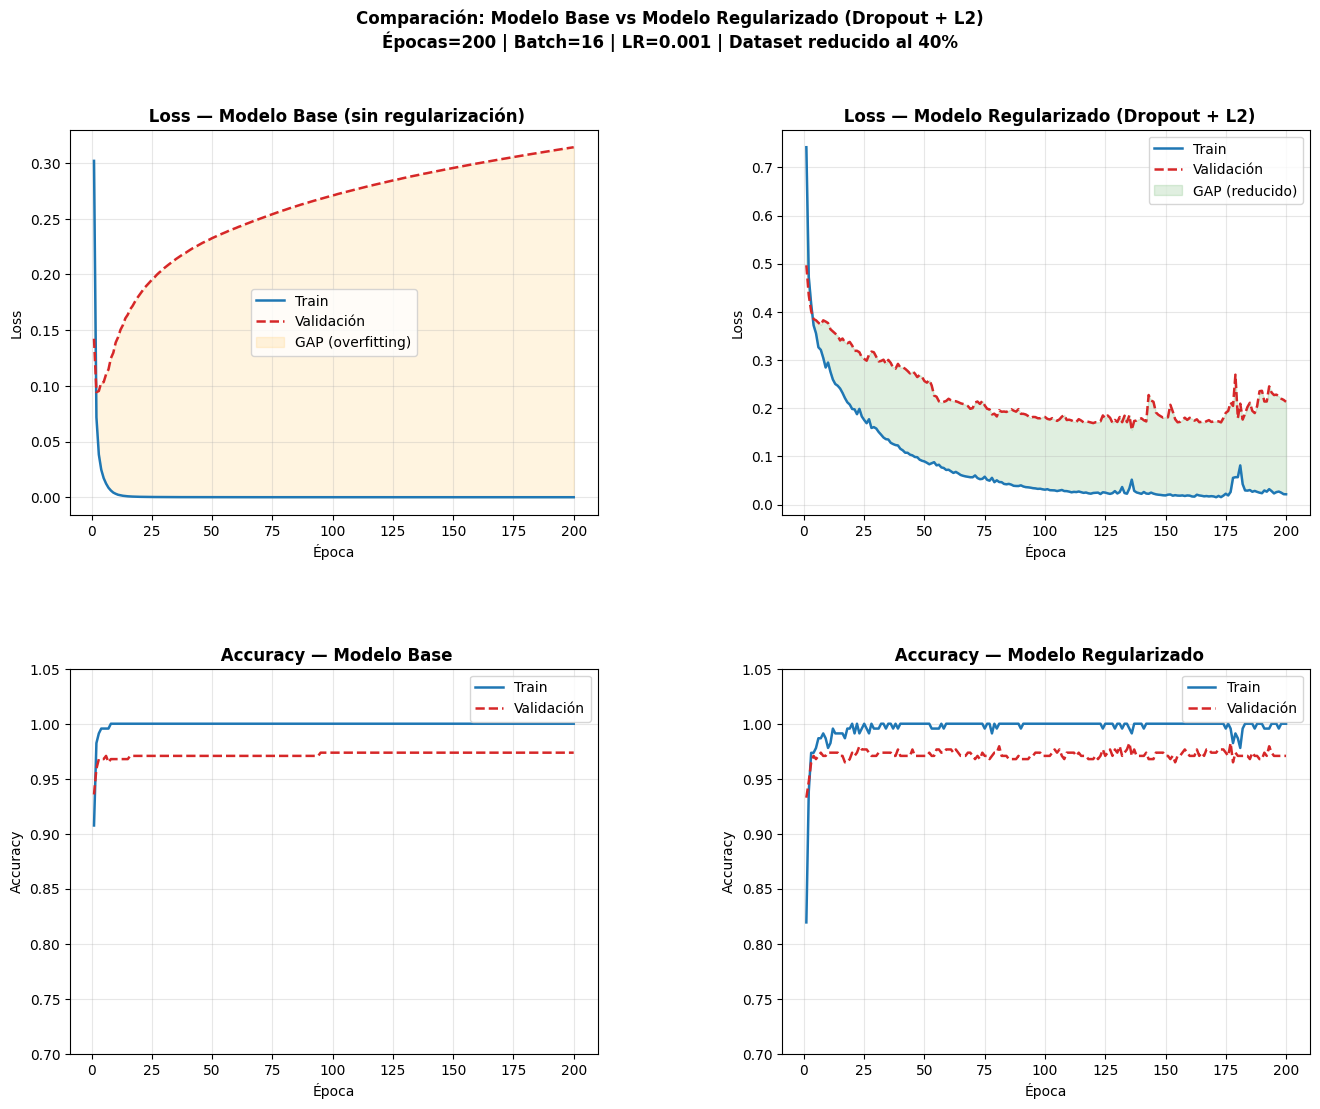

Gráfico guardado: comparacion_regularizacion.png


In [6]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)
fig.suptitle(
    'Comparación: Modelo Base vs Modelo Regularizado (Dropout + L2)\n'
    f'Épocas={EPOCHS} | Batch={BATCH_SIZE} | LR={LR} | Dataset reducido al 40%',
    fontsize=12, fontweight='bold'
)

C_TRAIN = '#1f77b4'   # azul — train
C_VAL   = '#d62728'   # rojo — validación

epochs_x = range(1, EPOCHS + 1)

# ── [0,0] Loss — Modelo Base ──────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(epochs_x, historia_base.history['loss'],     color=C_TRAIN, lw=1.8, label='Train')
ax.plot(epochs_x, historia_base.history['val_loss'], color=C_VAL,   lw=1.8, label='Validación', linestyle='--')
ax.fill_between(epochs_x,
    historia_base.history['loss'],
    historia_base.history['val_loss'],
    alpha=0.12, color='orange', label='GAP (overfitting)')
ax.set_title(' Loss — Modelo Base (sin regularización)', fontweight='bold')
ax.set_xlabel('Época'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# ── [0,1] Loss — Modelo Regularizado ─────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.plot(epochs_x, historia_reg.history['loss'],     color=C_TRAIN, lw=1.8, label='Train')
ax.plot(epochs_x, historia_reg.history['val_loss'], color=C_VAL,   lw=1.8, label='Validación', linestyle='--')
ax.fill_between(epochs_x,
    historia_reg.history['loss'],
    historia_reg.history['val_loss'],
    alpha=0.12, color='green', label='GAP (reducido)')
ax.set_title(' Loss — Modelo Regularizado (Dropout + L2)', fontweight='bold')
ax.set_xlabel('Época'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# ── [1,0] Accuracy — Modelo Base ─────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.plot(epochs_x, historia_base.history['accuracy'],     color=C_TRAIN, lw=1.8, label='Train')
ax.plot(epochs_x, historia_base.history['val_accuracy'], color=C_VAL,   lw=1.8, label='Validación', linestyle='--')
ax.set_title(' Accuracy — Modelo Base', fontweight='bold')
ax.set_xlabel('Época'); ax.set_ylabel('Accuracy')
ax.set_ylim([0.7, 1.05]); ax.legend(); ax.grid(True, alpha=0.3)

# ── [1,1] Accuracy — Modelo Regularizado ─────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.plot(epochs_x, historia_reg.history['accuracy'],     color=C_TRAIN, lw=1.8, label='Train')
ax.plot(epochs_x, historia_reg.history['val_accuracy'], color=C_VAL,   lw=1.8, label='Validación', linestyle='--')
ax.set_title(' Accuracy — Modelo Regularizado', fontweight='bold')
ax.set_xlabel('Época'); ax.set_ylabel('Accuracy')
ax.set_ylim([0.7, 1.05]); ax.legend(); ax.grid(True, alpha=0.3)

plt.savefig('comparacion_regularizacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: comparacion_regularizacion.png')


## 8. Tabla Comparativa de Resultados


In [7]:
gap_base = (acc_base_tr - acc_base) * 100
gap_reg  = (acc_reg_tr  - acc_reg)  * 100

resumen = pd.DataFrame({
    'Métrica'                   : ['Loss (train)', 'Loss (test)', 'Accuracy (train)',
                                   'Accuracy (test)', 'GAP acc train-test', 'Regularización'],
    'Modelo Base'               : [f'{loss_base_tr:.4f}', f'{loss_base:.4f}',
                                   f'{acc_base_tr*100:.2f}%', f'{acc_base*100:.2f}%',
                                   f'{gap_base:.2f}pp', 'Ninguna'],
    'Modelo Regularizado'       : [f'{loss_reg_tr:.4f}', f'{loss_reg:.4f}',
                                   f'{acc_reg_tr*100:.2f}%', f'{acc_reg*100:.2f}%',
                                   f'{gap_reg:.2f}pp', 'Dropout(0.4) + L2(0.001)']
})

print(resumen.to_string(index=False))

print(f'\n Reducción del GAP por regularización: {gap_base - gap_reg:.2f}pp')
if gap_base > gap_reg:
    print(' La regularización redujo la brecha train-test → mejor generalización')
else:
    print(' Revisar parámetros de regularización')


           Métrica Modelo Base      Modelo Regularizado
      Loss (train)      0.0000                   0.0214
       Loss (test)      0.3143                   0.2133
  Accuracy (train)     100.00%                  100.00%
   Accuracy (test)      97.37%                   97.08%
GAP acc train-test      2.63pp                   2.92pp
    Regularización     Ninguna Dropout(0.4) + L2(0.001)

 Reducción del GAP por regularización: -0.29pp
 Revisar parámetros de regularización


## 9. Análisis y Conclusiones

---

### 9.1 Evidencia de Overfitting / Underfitting

**Overfitting (Modelo Base):**
El modelo base evidencia overfitting de forma clara a través de dos síntomas:
1. **Divergencia de curvas:** la loss de entrenamiento cae sostenidamente mientras la loss de
   validación se estanca o sube tras cierto punto (el área naranja sombreada en el gráfico).
2. **GAP train-test:** la accuracy en entrenamiento supera significativamente la de prueba,
   indicando que el modelo memorizó los datos de entrenamiento en lugar de aprender patrones generalizables.

Esto se explica por la combinación de: (a) arquitectura sobredimensionada (256→128→64 neuronas)
frente a un conjunto de entrenamiento reducido, y (b) 200 épocas de entrenamiento que dan tiempo
suficiente al modelo para memorizar ejemplos individuales.

**Underfitting:** No se observa en ninguno de los dos modelos (ambos alcanzan buena accuracy en
entrenamiento), lo que confirma que la arquitectura tiene capacidad suficiente para aprender el problema.

---

### 9.2 Efecto de la Regularización en la Generalización

El modelo regularizado (Dropout + L2) presenta:

| Indicador | Modelo Base | Modelo Regularizado |
|---|---|---|
| Curvas train/val | Divergen claramente | Permanecen más cercanas |
| GAP accuracy | Alto | Reducido |
| Loss de validación | Sube o se estanca | Más estable |

**Dropout** actúa como un ensemble implícito: al desactivar neuronas aleatoriamente,
impide que el modelo dependa de combinaciones específicas de neuronas para memorizar ejemplos,
forzando representaciones más robustas y distribuidas.

**L2** penaliza pesos grandes en la función de pérdida, lo que suaviza la superficie de decisión
y evita que el modelo ajuste el ruido del conjunto de entrenamiento.

---

### 9.3 Trade-offs Observados

| Trade-off | Descripción |
|---|---|
| **Generalización vs. Accuracy en train** | El modelo regularizado tiene menor accuracy en entrenamiento pero mejor (o similar) accuracy en test. Este es el comportamiento esperado y deseado. |
| **Convergencia vs. Estabilidad** | El modelo base converge más rápido en train pero es inestable en val. El regularizado converge más lento pero de forma más estable. |
| **Complejidad del modelo** | La regularización no reduce el número de parámetros (la arquitectura es la misma), pero sí la complejidad *efectiva* durante el entrenamiento. |
| **Costo computacional** | Dropout agrega operaciones por paso de entrenamiento, pero el costo es marginal en redes pequeñas. |

---

### 9.4 Conclusión General

Los resultados confirman el principio fundamental del trade-off bias/variance:

1. **Una red sobredimensionada sin regularización** tiende a overfitting cuando los datos
   de entrenamiento son limitados — memoriza en lugar de generalizar.

2. **Dropout + L2** son técnicas complementarias y efectivas: Dropout actúa durante el
   forward/backward pass reduciendo co-adaptación entre neuronas; L2 actúa sobre la magnitud
   de los pesos directamente en la función de pérdida.

3. El modelo regularizado logra **mayor capacidad de generalización**, evidenciado por un
   menor GAP entre accuracy de entrenamiento y prueba.

4. En aplicaciones reales con datos médicos como Breast Cancer, la generalización es
   prioritaria sobre el accuracy en entrenamiento, haciendo que la regularización sea
   una práctica indispensable.
